Step 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

2 — Upload file

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

if not uploaded:
    print("No file was uploaded. Please upload an Excel file.")
else:
    file_name = list(uploaded.keys())[0]
    try:
        performance_df = pd.read_excel(file_name)
        print(performance_df.shape)
        performance_df.head()
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        print("Please ensure the uploaded file is a valid Excel file and not corrupted.")

Saving Performance_Dataset_June2026.xlsx to Performance_Dataset_June2026.xlsx
(4217, 17)


3 — Check columns

In [3]:
performance_df.columns.tolist()

['task_id',
 'task_code',
 'task_name',
 'wbs_id',
 'target_start_date',
 'target_end_date',
 'baseline_duration_days',
 'total_float_hr_cnt',
 'planned_percent',
 'actual_percent',
 'progress_variance',
 'budget_cost',
 'PV',
 'EV',
 'AC',
 'SPI',
 'CPI']

Module 1 — Root Cause Analysis

Schedule Flag

In [4]:
performance_df["schedule_issue"] = (
    performance_df["SPI"] < 0.90
)

Cost Flag

Progress Flag

In [5]:
performance_df["cost_issue"] = (
    performance_df["CPI"] < 0.90
)

Float Flag

In [6]:
performance_df["progress_issue"] = (
    performance_df["progress_variance"] < -10
)

In [7]:
performance_df["float_days"] = (
    pd.to_numeric(
        performance_df["total_float_hr_cnt"],
        errors="coerce"
    ) / 8
)

In [8]:
performance_df["float_issue"] = (
    performance_df["float_days"] <= 5
)

print(
    "Schedule Issues:",
    performance_df["schedule_issue"].sum()
)

print(
    "Cost Issues:",
    performance_df["cost_issue"].sum()
)

print(
    "Progress Issues:",
    performance_df["progress_issue"].sum()
)

print(
    "Float Issues:",
    performance_df["float_issue"].sum()
)

Schedule Issues: 1373
Cost Issues: 2266
Progress Issues: 1367
Float Issues: 524


Module 2 — Dynamic Risk Scoring

Step 1 — Schedule Risk Score

In [9]:
performance_df["schedule_risk"] = np.where(
    performance_df["SPI"] < 0.80,
    100,
    np.where(
        performance_df["SPI"] < 0.90,
        70,
        np.where(
            performance_df["SPI"] < 1.0,
            40,
            10
        )
    )
)

Step 2 — Cost Risk Score

In [10]:
performance_df["cost_risk"] = np.where(
    performance_df["CPI"] < 0.80,
    100,
    np.where(
        performance_df["CPI"] < 0.90,
        70,
        np.where(
            performance_df["CPI"] < 1.0,
            40,
            10
        )
    )
)

Step 3 — Progress Risk Score

In [11]:
performance_df["progress_risk"] = np.where(
    performance_df["progress_variance"] < -20,
    100,
    np.where(
        performance_df["progress_variance"] < -10,
        70,
        np.where(
            performance_df["progress_variance"] < 0,
            40,
            10
        )
    )
)

Step 4 — Float Risk Score

In [12]:
performance_df["float_risk"] = np.where(
    performance_df["float_days"] <= 0,
    100,
    np.where(
        performance_df["float_days"] <= 5,
        70,
        np.where(
            performance_df["float_days"] <= 15,
            40,
            10
        )
    )
)

Step 5 — Dynamic Risk Score

In [13]:
performance_df["dynamic_risk_score"] = (
    0.35 * performance_df["schedule_risk"]
    +
    0.35 * performance_df["cost_risk"]
    +
    0.20 * performance_df["progress_risk"]
    +
    0.10 * performance_df["float_risk"]
)

Step 6 — Risk Categories

In [14]:
performance_df["risk_category"] = np.where(
    performance_df["dynamic_risk_score"] >= 80,
    "Very High",
    np.where(
        performance_df["dynamic_risk_score"] >= 60,
        "High",
        np.where(
            performance_df["dynamic_risk_score"] >= 40,
            "Medium",
            "Low"
        )
    )
)

Step 7 — Executive View

In [15]:
performance_df["risk_category"].value_counts()

,count
risk_category,
Low,2140
High,1051
Medium,939
Very High,87


Step 8 — Top Exposure Activities

In [16]:
top_risks = (
    performance_df
    .sort_values(
        by="dynamic_risk_score",
        ascending=False
    )
    [
        [
            "task_code",
            "task_name",
            "SPI",
            "CPI",
            "progress_variance",
            "float_days",
            "dynamic_risk_score",
            "risk_category"
        ]
    ]
    .head(20)
)

top_risks

,task_code,task_name,SPI,CPI,progress_variance,float_days,dynamic_risk_score,risk_category
2485,HCMEB4Z5220,B4 Z4 :Cable Tray Installation,0.80,0.718135,-20,45.0,85.0,Very High
596,HCSW2FZ1070,Installation of steel columns and beams,0.84,0.769784,-16,0.0,83.5,Very High
608,HCSW2FZ2090,Casting concrete for slab topping,0.80,0.686245,-20,0.0,83.5,Very High
2359,HMMOAZ050,Removal of Tower crane # 1,0.82,0.738517,-18,0.0,83.5,Very High
1750,HCFWF2Z3069,F2 Z3 :Plaster Final Layer,0.81,0.749215,-19,0.0,83.5,Very High
570,HCESCN010,s/c nomination: Steel structure subcontractor,0.86,0.715090,-14,0.0,83.5,Very High
664,HCSW4FZ3090,Casting concrete for slab topping,0.81,0.700653,-19,0.0,83.5,Very High
1759,HCFWF2Z3096,F2 Z3 :Plaster Second Layer,0.82,0.724219,-18,0.0,83.5,Very High
652,HCSW4FZ2070,Installation of steel columns and beams,0.86,0.756993,-14,0.0,83.5,Very High
2077,HCFWF5Z3177,F5 Z3 :Trawelled smooth Concrete screed,0.80,0.652802,-20,0.0,83.5,Very High


Module 3 — Forecast Completion Engine

Step 1 — Forecast Duration

In [17]:
performance_df["forecast_duration_days"] = (
    performance_df["baseline_duration_days"]
    / performance_df["SPI"]
)

Step 2 — Delay Forecast

In [18]:
performance_df["forecast_delay_days"] = (
    performance_df["forecast_duration_days"]
    -
    performance_df["baseline_duration_days"]
)

Step 3 — Risk Escalation

In [19]:
performance_df["escalation_level"] = np.where(
    performance_df["forecast_delay_days"] > 30,
    "Executive",
    np.where(
        performance_df["forecast_delay_days"] > 15,
        "Project Manager",
        "Monitor"
    )
)

Step 4 — Top Delay Drivers

In [20]:
top_delay_drivers = (
    performance_df
    .sort_values(
        by="forecast_delay_days",
        ascending=False
    )
    [
        [
            "task_code",
            "task_name",
            "baseline_duration_days",
            "SPI",
            "forecast_duration_days",
            "forecast_delay_days",
            "escalation_level"
        ]
    ]
    .head(20)
)

top_delay_drivers

,task_code,task_name,baseline_duration_days,SPI,forecast_duration_days,forecast_delay_days,escalation_level
3770,HCSDAMEP010,SD approval: MEP Plans & Details,398,0.80,497.500000,99.500000,Executive
3765,HEPSCVS0010,Manufacturing & Importing Materials,364,0.83,438.554217,74.554217,Executive
3897,HEPSAME1180,Windows Washing Machine,291,0.83,350.602410,59.602410,Executive
858,HEPSAME1300,CableTrays,287,0.83,345.783133,58.783133,Executive
857,HEPSAME1290,Cables,262,0.83,315.662651,53.662651,Executive
849,HEPSAFI0270,Toilet Toilet & corian vanity tops,214,0.80,267.500000,53.500000,Executive
866,HEPSAAL0060,Glass panels,237,0.86,275.581395,38.581395,Executive
864,HEPSAAL0030,Sky lights,364,0.91,400.000000,36.000000,Executive
3708,HCFWAFAZ000,Finish Left over areas (Crane #3),169,0.84,201.190476,32.190476,Executive
854,HEPSAME1130,Ducts & pipes,189,0.86,219.767442,30.767442,Executive


Module 4-Portfolio Exposure

In [21]:
 total_delay_exposure = (
    performance_df["forecast_delay_days"]
    .sum()
)

print(
    "Total Forecast Delay Exposure:",
    round(total_delay_exposure,1),
    "days"
)

Total Forecast Delay Exposure: 4938.5 days


Executive Delay Distribution

In [22]:
delay_summary = (
    performance_df
    .groupby("escalation_level")
    ["forecast_delay_days"]
    .sum()
    .reset_index()
)

delay_summary

,escalation_level,forecast_delay_days
0,Executive,537.141723
1,Monitor,4204.914989
2,Project Manager,196.445142


Module 5 – Performance Monte Carlo

Step 1 — Create SPI Scenarios

In [23]:
performance_df["optimistic_spi"] = (
    performance_df["SPI"] * 1.10
)

performance_df["most_likely_spi"] = (
    performance_df["SPI"]
)

performance_df["pessimistic_spi"] = (
    performance_df["SPI"] * 0.90
)

Step 2 — Avoid impossible SPI values

In [24]:
performance_df["optimistic_spi"] = (
    performance_df["optimistic_spi"]
    .clip(0.1, 1)
)

performance_df["most_likely_spi"] = (
    performance_df["most_likely_spi"]
    .clip(0.1, 1)
)

performance_df["pessimistic_spi"] = (
    performance_df["pessimistic_spi"]
    .clip(0.1, 1)
)

Step 3 — Simulated Forecast Durations

Optimistic

In [25]:
performance_df["optimistic_duration"] = (
    performance_df["baseline_duration_days"]
    /
    performance_df["optimistic_spi"]
)

Most Likely

In [26]:
performance_df["most_likely_duration"] = (
    performance_df["baseline_duration_days"]
    /
    performance_df["most_likely_spi"]
)

Pessimistic

In [27]:
performance_df["pessimistic_duration"] = (
    performance_df["baseline_duration_days"]
    /
    performance_df["pessimistic_spi"]
)

Check a few rows

In [28]:
performance_df[
    [
        "task_code",
        "SPI",
        "optimistic_duration",
        "most_likely_duration",
        "pessimistic_duration"
    ]
].head()

,task_code,SPI,optimistic_duration,most_likely_duration,pessimistic_duration
0,HCSWSSZ1000,0.86,15.856237,17.441860,19.379845
1,HCSWSSZ1010,0.99,13.000000,13.131313,14.590348
2,HMMOAZ000,1.00,14.000000,14.000000,15.555556
3,HMMOAZ010,0.94,22.000000,23.404255,26.004728
4,HMMOAZ020,0.90,25.252525,27.777778,30.864198


Step 1 – Number of simulations

In [29]:
n_simulations = 5000
simulation_results = []

Step 2 – Run simulations

In [30]:
for i in range(n_simulations):

    simulated_project_duration = 0

    for _, row in performance_df.iterrows():

        simulated_duration = np.random.triangular(
            row["optimistic_duration"],
            row["most_likely_duration"],
            row["pessimistic_duration"]
        )

        simulated_project_duration += simulated_duration

    simulation_results.append(
        simulated_project_duration
    )

Step 3 – Convert to numpy array

In [31]:
simulation_results = np.array(
    simulation_results
)

Step 4 – Calculate percentiles

In [32]:
p50 = np.percentile(simulation_results, 50)
p80 = np.percentile(simulation_results, 80)
p90 = np.percentile(simulation_results, 90)

print("P50:", round(p50,1))
print("P80:", round(p80,1))
print("P90:", round(p90,1))

P50: 70795.0
P80: 70861.9
P90: 70899.2


Step 5 – Plot the distribution

In [33]:
n_simulations = 5000
simulation_results = []

for i in range(n_simulations):

    simulated_durations = np.random.triangular(
        performance_df["optimistic_duration"],
        performance_df["most_likely_duration"],
        performance_df["pessimistic_duration"]
    )

    simulated_project_duration = simulated_durations.max()

    simulation_results.append(simulated_project_duration)

simulation_results = np.array(simulation_results)

p50 = np.percentile(simulation_results, 50)
p80 = np.percentile(simulation_results, 80)
p90 = np.percentile(simulation_results, 90)

print("P50:", round(p50, 1))
print("P80:", round(p80, 1))
print("P90:", round(p90, 1))

P50: 500.2
P80: 520.0
P90: 529.8


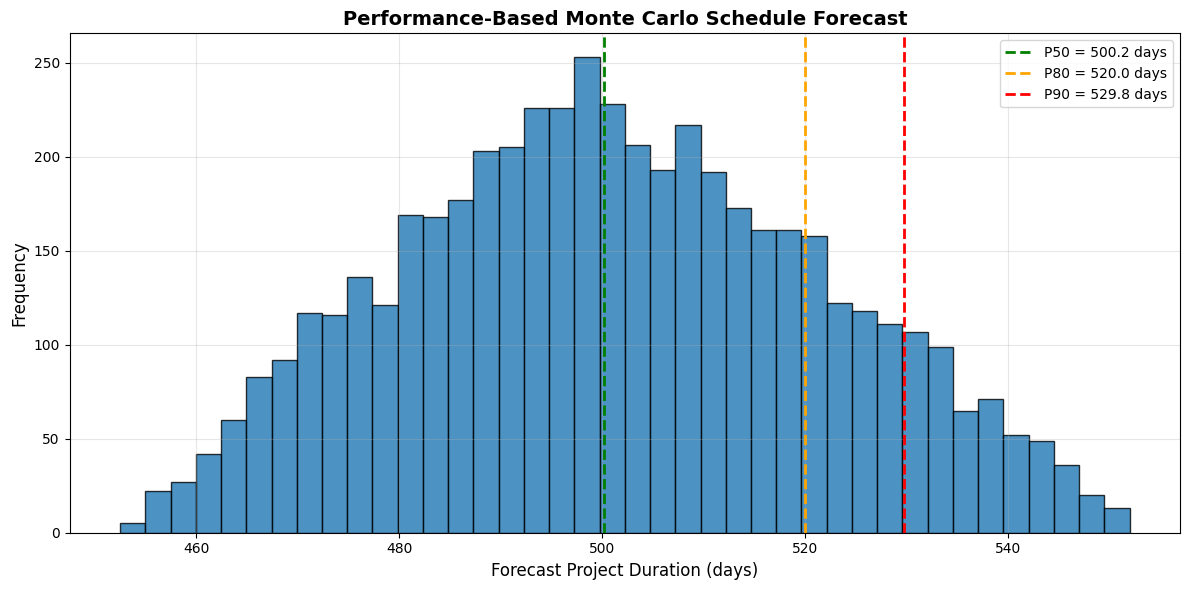

In [34]:
plt.figure(figsize=(12,6))

plt.hist(
    simulation_results,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    p50,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"P50 = {p50:.1f} days"
)

plt.axvline(
    p80,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"P80 = {p80:.1f} days"
)

plt.axvline(
    p90,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"P90 = {p90:.1f} days"
)

plt.xlabel("Forecast Project Duration (days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title(
    "Performance-Based Monte Carlo Schedule Forecast",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1 – Create Executive Summary

In [35]:
total_baseline_duration = performance_df["baseline_duration_days"].sum()

if p90 > total_baseline_duration * 1.10:
    project_status = "At Risk: Significant Delay Predicted"
elif p90 > total_baseline_duration * 1.05:
    project_status = "Monitor: Potential Delays"
else:
    project_status = "On Track"

executive_summary = pd.DataFrame({
    "Metric": [
        "Project Status",
        "P50 Duration (days)",
        "P80 Duration (days)",
        "P90 Duration (days)",
        "Schedule Issues",
        "Cost Issues",
        "Progress Issues",
        "Float Issues",
        "Very High Risk Activities"
    ],
    "Value": [
        project_status,
        round(p50,1),
        round(p80,1),
        round(p90,1),
        performance_df["schedule_issue"].sum(),
        performance_df["cost_issue"].sum(),
        performance_df["progress_issue"].sum(),
        performance_df["float_issue"].sum(),
        (performance_df["risk_category"]=="Very High").sum()
    ]
})

executive_summary

,Metric,Value
0,Project Status,On Track
1,P50 Duration (days),500.2
2,P80 Duration (days),520.0
3,P90 Duration (days),529.8
4,Schedule Issues,1373
5,Cost Issues,2266
6,Progress Issues,1367
7,Float Issues,524
8,Very High Risk Activities,87


Step 2 – Create Recommendations

In [36]:
recommendations = []

# Calculate project-level SPI and CPI
total_ev = performance_df['EV'].sum()
total_pv = performance_df['PV'].sum()
total_ac = performance_df['AC'].sum()

project_SPI = total_ev / total_pv if total_pv != 0 else 0
project_CPI = total_ev / total_ac if total_ac != 0 else 0

if project_SPI < 0.90:
    recommendations.append(
        "Develop and implement a schedule recovery plan."
    )

if project_CPI < 0.90:
    recommendations.append(
        "Conduct cost review and strengthen cost controls."
    )

if p80 > p50 + 15:
    recommendations.append(
        "Schedule uncertainty is moderate. Monitor critical packages closely."
    )

if (performance_df["risk_category"]=="Very High").sum() > 50:
    recommendations.append(
        "Conduct executive review of very high-risk activities."
    )

recommendations_df = pd.DataFrame(
    {"Recommendations": recommendations}
)

recommendations_df

,Recommendations
0,Conduct cost review and strengthen cost controls.
1,Schedule uncertainty is moderate. Monitor crit...
2,Conduct executive review of very high-risk act...


Step 3 – Export Report

In [37]:
with pd.ExcelWriter(
    "Performance_Driven_Risk_Forecasting_V03_Report.xlsx"
) as writer:

    executive_summary.to_excel(
        writer,
        sheet_name="Executive Summary",
        index=False
    )

    top_risks.to_excel(
        writer,
        sheet_name="Top Risks",
        index=False
    )

    top_delay_drivers.to_excel(
        writer,
        sheet_name="Top Delay Drivers",
        index=False
    )

    recommendations_df.to_excel(
        writer,
        sheet_name="Recommendations",
        index=False
    )

print("Report exported successfully.")

Report exported successfully.


Step 4 – Download

In [38]:
from google.colab import files
files.download(
    "Performance_Driven_Risk_Forecasting_V03_Report.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>